In [1]:
# Cell 1: Installs (run once per fresh Studio session)
!pip install -q timm pytorch-lightning torchmetrics seaborn scikit-learn thop


In [ ]:
# Cell 2: CONFIG — the only cell you ever edit between models
class Config:
    # ---- Path ----
    DATA_ROOT = "/teamspace/studios/this_studio/HVDROPDB_RetCam_Neo_Classification"

    # ---- THE TWO LINES YOU CHANGE PER MODEL ----
    MODEL_KEY = "resnet18"                # short name -> used for folder/file naming
    BACKBONE  = "resnet18"                # exact timm model string
 
    # ---- Reproducibility ----
    SEED = 42

    # ---- Data ----
    IMG_SIZE = 224
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    VAL_FRAC = 0.15
    TEST_FRAC = 0.15

    # ---- Model ----
    PRETRAINED = True
    NUM_CLASSES = 1                       # binary head -> BCEWithLogitsLoss

    # ---- Training ----
    LR = 1e-5                             # safe default for full fine-tuning; raise to 1e-4/1e-3 only for small CNNs if loss plateaus near ln(2)=0.693
    MAX_EPOCHS = 30

    # ---- Class mapping ----
    LABEL_MAP = {"Normal": 0, "ROP": 1}

    # ---- Output ----
    RESULTS_ROOT = "results"


In [3]:
# Cell 3: Imports
import os, random, time, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import timm
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from torchvision import transforms
from PIL import Image

from torchmetrics.classification import (
    BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAccuracy
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, precision_recall_curve, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score
)


In [4]:
# Cell 4: Seed + GPU detection + output folders
def set_seed(seed=Config.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU attached to this session — check Studio compute type before training.")

MODEL_DIR = os.path.join(Config.RESULTS_ROOT, Config.MODEL_KEY)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.join(MODEL_DIR, "figures"), exist_ok=True)
print(f"Outputs will be saved to: {MODEL_DIR}/")


Device: cuda
GPU: Tesla T4
Outputs will be saved to: results/resnet18/


In [5]:
# Cell 5: Build file index — walk Normal/{Neo_Normal,RetCam_Normal} and ROP/{Neo_ROP,RetCam_ROP}
def build_index(data_root):
    records = []
    if not os.path.exists(data_root):
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")
    for cls_name, label in Config.LABEL_MAP.items():
        cls_dir = os.path.join(data_root, cls_name)
        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f"Missing class folder: {cls_dir}")
        camera_subdirs = [d for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
        if not camera_subdirs:
            raise FileNotFoundError(f"No camera subfolders found inside: {cls_dir}")
        for camera_subdir in camera_subdirs:
            camera = "Neo" if camera_subdir.startswith("Neo") else "RetCam"
            sub_path = os.path.join(cls_dir, camera_subdir)
            n_before = len(records)
            for fname in os.listdir(sub_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    records.append({"filepath": os.path.join(sub_path, fname),
                                     "label": label, "class_name": cls_name, "camera": camera})
            print(f"{cls_name}/{camera_subdir}: {len(records) - n_before} images")
    if not records:
        raise ValueError("No images found — check file extensions or folder structure.")
    return pd.DataFrame(records)

df = build_index(Config.DATA_ROOT)
print(f"\nTotal images: {len(df)}  (expected: 185 — if different, your dataset upload is incomplete, fix before training)")
df.groupby(["class_name", "camera"]).size()


Normal/Neo_Normal: 50 images
Normal/RetCam_Normal: 50 images
ROP/Neo_ROP: 35 images
ROP/RetCam_ROP: 50 images

Total images: 185  (expected: 185 — if different, your dataset upload is incomplete, fix before training)


class_name  camera
Normal      Neo       50
            RetCam    50
ROP         Neo       35
            RetCam    50
dtype: int64

In [6]:
# Cell 6: Stratified 70/15/15 split by class AND camera — IDENTICAL for every model, do not change
df["strata"] = df["class_name"] + "_" + df["camera"]

train_df, temp_df = train_test_split(
    df, test_size=(Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=df["strata"], random_state=Config.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=Config.TEST_FRAC / (Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=temp_df["strata"], random_state=Config.SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 129 | Val: 28 | Test: 28


In [7]:
# Cell 7: Transforms + Dataset + DataLoaders
train_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomResizedCrop(Config.IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ROPDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, torch.tensor(row["label"], dtype=torch.float32)

train_ds = ROPDataset(train_df, train_tf)
val_ds   = ROPDataset(val_df, eval_tf)
test_ds  = ROPDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)


## Model — SWAP-PROOF (works for every architecture, including GhostNetV2's quirky feature-dim reporting)

In [8]:
# Cell 8: Model definition — architecture-agnostic, do not edit per model
class ROPBackbone(nn.Module):
    def __init__(self, backbone_name=Config.BACKBONE, pretrained=Config.PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        # Probe real output dim via a dummy forward pass instead of trusting .num_features
        # (.num_features is wrong for some architectures, e.g. GhostNetV2 — this fixes it for all of them)
        with torch.no_grad():
            dummy = torch.randn(1, 3, Config.IMG_SIZE, Config.IMG_SIZE)
            feat_dim = self.backbone(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, Config.NUM_CLASSES)
        )
    def forward(self, x):
        return self.head(self.backbone(x)).squeeze(1)


In [9]:
# Cell 9: LightningModule — identical for every model
class ROPClassifier(pl.LightningModule):
    def __init__(self, lr=Config.LR):
        super().__init__()
        self.save_hyperparameters()
        self.model = ROPBackbone()
        self.criterion = nn.BCEWithLogitsLoss()
        for split in ["train", "val", "test"]:
            setattr(self, f"{split}_acc", BinaryAccuracy())
            setattr(self, f"{split}_prec", BinaryPrecision())
            setattr(self, f"{split}_rec", BinaryRecall())
            setattr(self, f"{split}_f1", BinaryF1Score())

    def forward(self, x):
        return self.model(x)

    def _step(self, batch, split):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        getattr(self, f"{split}_acc")(preds, y.int())
        getattr(self, f"{split}_prec")(preds, y.int())
        getattr(self, f"{split}_rec")(preds, y.int())
        getattr(self, f"{split}_f1")(preds, y.int())
        self.log(f"{split}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_acc", getattr(self, f"{split}_acc"), prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_precision", getattr(self, f"{split}_prec"), on_epoch=True, on_step=False)
        self.log(f"{split}_recall", getattr(self, f"{split}_rec"), on_epoch=True, on_step=False)
        self.log(f"{split}_f1", getattr(self, f"{split}_f1"), on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx): return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): return self._step(batch, "val")
    def test_step(self, batch, batch_idx): return self._step(batch, "test")
    def configure_optimizers(self): return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [10]:
# Cell 10: Trainer setup — logger auto-named from Config.MODEL_KEY, nothing to edit
checkpoint_cb = ModelCheckpoint(
    monitor="val_f1", mode="max", save_top_k=1,
    dirpath=os.path.join(MODEL_DIR, "checkpoints"),
    filename="best-{epoch:02d}-{val_f1:.4f}"
)
logger = CSVLogger(Config.RESULTS_ROOT, name=f"{Config.MODEL_KEY}_logs")

model = ROPClassifier()

trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb],
    logger=logger,
    log_every_n_steps=10,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
# Cell 11: Train — timed
start_time = time.time()
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
training_time_sec = time.time() - start_time
print(f"\nTraining time: {training_time_sec/60:.2f} min")


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/results/resnet18/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ ROPBackbone       │ 11.2 M │ train │     0 │
│ 1  │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2  │ train_acc  │ BinaryAccuracy    │      0 │ train │     0 │
│ 3  │ train_prec │ BinaryPrecision   │      0 │ train │     0 │
│ 4  │ train_rec  │ BinaryRecall      │      0 │ train │     0 │
│ 5  │ train_f1   │ BinaryF1Score     │      0 │ train │     0 │
│ 6  │ val_acc    │ BinaryAccuracy    │      0 │ train │     0 │
│ 7  │ val_prec   │ BinaryPrecision   │      0 │ train │     0 │
│ 8  │ val_rec    │ BinaryRecall      │      0 │ train │     0 │
│ 9  │ val_f1     │ BinaryF1Score     │      0 │ train │     0 │
│ 10 │ test_acc   │ BinaryAccuracy    │      0 │ train │     0 │
│ 11 │ test_prec  │ BinaryPrecision   │      0 │ train │     0 │
│ 12 │ test_rec   │ BinaryRecall      │      0 │ train │     0 │
│ 13 │ test_f1    │ BinaryF1Score     │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.969                                                                     
Modules in train mode: 113                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=30` reached.



Training time: 2.94 min


In [12]:
# Cell 12: Reload best checkpoint for evaluation (train/val/test all evaluated cleanly, no augmentation)
best_ckpt_path = checkpoint_cb.best_model_path
print("Best checkpoint:", best_ckpt_path)

eval_model = ROPClassifier.load_from_checkpoint(best_ckpt_path)
eval_model.to(device).eval()

# Clean (no-augmentation) loaders for fair train/val/test comparison
train_eval_loader = DataLoader(ROPDataset(train_df, eval_tf), batch_size=Config.BATCH_SIZE, shuffle=False)


Best checkpoint: /teamspace/studios/this_studio/results/resnet18/checkpoints/best-epoch=00-val_f1=0.5833.ckpt


In [13]:
# Cell 13: Full evaluation function — every metric you asked for, in one place
def evaluate(model, loader, dataframe=None):
    y_true, y_pred, y_probs = [], [], []
    inference_times = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            logits = model(images)
            if device.type == "cuda": torch.cuda.synchronize()
            inference_times.append((time.perf_counter() - t0) / images.size(0))

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            y_true.extend(labels.numpy()); y_pred.extend(preds); y_probs.extend(probs)

    y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=["Normal", "ROP"], output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "accuracy": report["accuracy"],
        "precision": report["ROP"]["precision"],
        "recall_sensitivity": report["ROP"]["recall"],
        "specificity": specificity,
        "f1_score": report["ROP"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, y_probs),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohens_kappa": cohen_kappa_score(y_true, y_pred),
        "avg_inference_time_sec_per_image": float(np.mean(inference_times)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }

    # Per-camera breakdown, if dataframe with camera column is provided
    if dataframe is not None:
        d = dataframe.reset_index(drop=True).copy()
        d["pred"] = y_pred
        for cam in ["Neo", "RetCam"]:
            sub = d[d["camera"] == cam]
            if len(sub) > 0:
                metrics[f"{cam.lower()}_accuracy"] = float((sub["pred"] == sub["label"]).mean())
                metrics[f"{cam.lower()}_n"] = len(sub)

    return metrics, y_true, y_pred, y_probs


In [14]:
# Cell 14: Run evaluation on train / val / test
train_metrics, *_ = evaluate(eval_model, train_eval_loader, train_df)
val_metrics, *_ = evaluate(eval_model, val_loader, val_df)
test_metrics, y_true_test, y_pred_test, y_probs_test = evaluate(eval_model, test_loader, test_df)

print("TRAIN:", {k: v for k, v in train_metrics.items() if k != "confusion_matrix"})
print("VAL:  ", {k: v for k, v in val_metrics.items() if k != "confusion_matrix"})
print("TEST: ", {k: v for k, v in test_metrics.items() if k != "confusion_matrix"})


TRAIN: {'accuracy': 0.5658914728682171, 'precision': 0.5283018867924528, 'recall_sensitivity': 0.4745762711864407, 'specificity': 0.6428571428571429, 'f1_score': 0.5, 'roc_auc': 0.6152542372881356, 'balanced_accuracy': 0.5587167070217918, 'mcc': 0.11891098643072058, 'cohens_kappa': 0.11837930192824009, 'avg_inference_time_sec_per_image': 0.001076860933855695, 'neo_accuracy': 0.576271186440678, 'neo_n': 59, 'retcam_accuracy': 0.5571428571428572, 'retcam_n': 70}
VAL:   {'accuracy': 0.6428571428571429, 'precision': 0.6363636363636364, 'recall_sensitivity': 0.5384615384615384, 'specificity': 0.7333333333333333, 'f1_score': 0.5833333333333334, 'roc_auc': 0.6564102564102565, 'balanced_accuracy': 0.6358974358974359, 'mcc': 0.27754778174292477, 'cohens_kappa': 0.27461139896373066, 'avg_inference_time_sec_per_image': 0.0011539281562704673, 'neo_accuracy': 0.5833333333333334, 'neo_n': 12, 'retcam_accuracy': 0.6875, 'retcam_n': 16}
TEST:  {'accuracy': 0.6071428571428571, 'precision': 0.6, 'recall

In [15]:
# Cell 15: Model size stats (params) — for your comparison table
num_params = sum(p.numel() for p in eval_model.parameters())
trainable_params = sum(p.numel() for p in eval_model.parameters() if p.requires_grad)
print(f"Total params: {num_params:,} | Trainable: {trainable_params:,}")


Total params: 11,242,305 | Trainable: 11,242,305


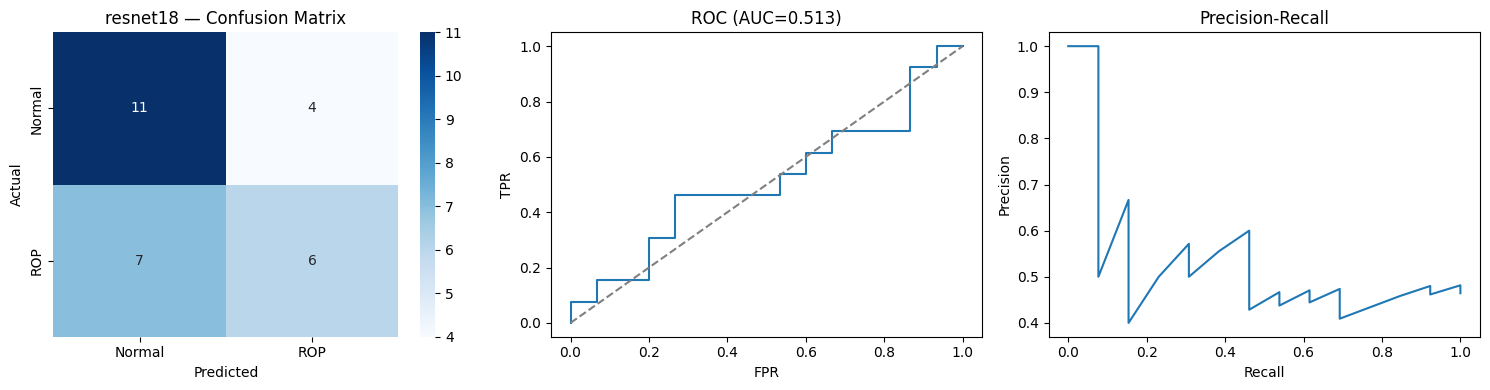

In [16]:
# Cell 16: Confusion matrix + ROC + PR curves — saved as figures
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cm = np.array(test_metrics["confusion_matrix"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=axes[0])
axes[0].set_title(f"{Config.MODEL_KEY} — Confusion Matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_true_test, y_probs_test)
axes[1].plot(fpr, tpr); axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title(f"ROC (AUC={test_metrics['roc_auc']:.3f})"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_true_test, y_probs_test)
axes[2].plot(rec, prec); axes[2].set_title("Precision-Recall"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "eval_curves.png"), dpi=150)
plt.show()


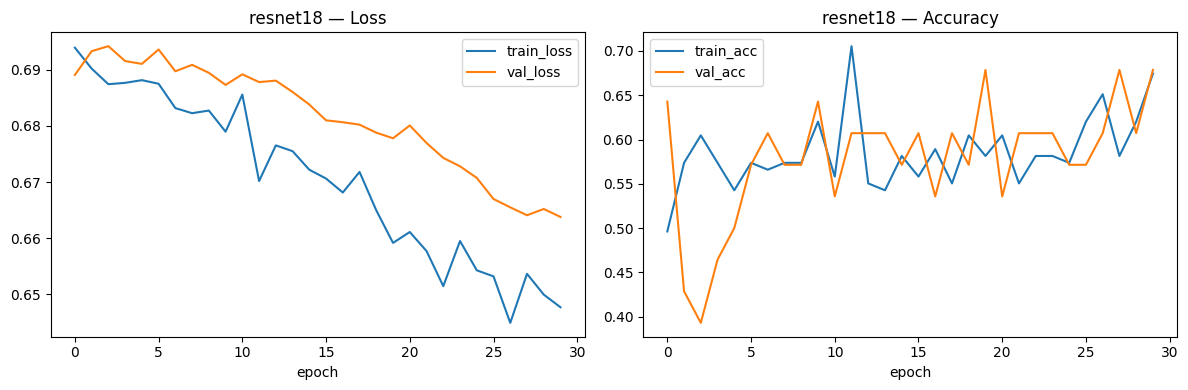

In [17]:
# Cell 17: Loss / accuracy curves from training log
log_path = os.path.join(logger.log_dir, "metrics.csv")
metrics_df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cols, ax, title in [(["train_loss","val_loss"], axes[0], "Loss"), (["train_acc","val_acc"], axes[1], "Accuracy")]:
    for c in cols:
        if c in metrics_df.columns:
            sub = metrics_df.dropna(subset=[c])
            ax.plot(sub["epoch"], sub[c], label=c)
    ax.set_title(f"{Config.MODEL_KEY} — {title}"); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "training_curves.png"), dpi=150)
plt.show()


In [18]:
# Cell 18: Save everything — predictions CSV, metrics CSV, and append to master comparison table
# Predictions
pred_df = test_df.reset_index(drop=True).copy()
pred_df["y_true"] = y_true_test
pred_df["y_pred"] = y_pred_test
pred_df["y_prob"] = y_probs_test
pred_df.to_csv(os.path.join(MODEL_DIR, "predictions.csv"), index=False)

# Per-model metrics CSV (train/val/test rows)
per_model_df = pd.DataFrame({"train": train_metrics, "val": val_metrics, "test": test_metrics}).T
per_model_df.to_csv(os.path.join(MODEL_DIR, "metrics.csv"))

# Save the model summary as JSON too (easy to reload later)
with open(os.path.join(MODEL_DIR, "summary.json"), "w") as f:
    json.dump({
        "model_key": Config.MODEL_KEY, "backbone": Config.BACKBONE,
        "checkpoint": best_ckpt_path, "num_params": num_params,
        "training_time_sec": training_time_sec,
        "train": train_metrics, "val": val_metrics, "test": test_metrics,
    }, f, indent=2)

# ---- Append one row to the shared master comparison table across all 6 models ----
master_path = os.path.join(Config.RESULTS_ROOT, "master_comparison.csv")
row = {
    "model": Config.MODEL_KEY,
    "backbone": Config.BACKBONE,
    "num_params": num_params,
    "training_time_min": round(training_time_sec / 60, 2),
    "train_accuracy": train_metrics["accuracy"],
    "val_accuracy": val_metrics["accuracy"],
    "test_accuracy": test_metrics["accuracy"],
    "precision": test_metrics["precision"],
    "recall_sensitivity": test_metrics["recall_sensitivity"],
    "specificity": test_metrics["specificity"],
    "f1_score": test_metrics["f1_score"],
    "roc_auc": test_metrics["roc_auc"],
    "balanced_accuracy": test_metrics["balanced_accuracy"],
    "mcc": test_metrics["mcc"],
    "cohens_kappa": test_metrics["cohens_kappa"],
    "neo_accuracy": test_metrics.get("neo_accuracy"),
    "retcam_accuracy": test_metrics.get("retcam_accuracy"),
    "avg_inference_time_sec_per_image": test_metrics["avg_inference_time_sec_per_image"],
    "confusion_matrix": test_metrics["confusion_matrix"],
    "checkpoint_path": best_ckpt_path,
}

if os.path.exists(master_path):
    master_df = pd.read_csv(master_path)
    master_df = master_df[master_df["model"] != Config.MODEL_KEY]   # replace if rerun
    master_df = pd.concat([master_df, pd.DataFrame([row])], ignore_index=True)
else:
    master_df = pd.DataFrame([row])

master_df.to_csv(master_path, index=False)
print(f"\n✅ Saved: {MODEL_DIR}/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)")
print(f"✅ Appended to: {master_path}")
master_df



✅ Saved: results/resnet18/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)
✅ Appended to: results/master_comparison.csv


,model,backbone,num_params,training_time_min,train_accuracy,val_accuracy,test_accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,balanced_accuracy,mcc,cohens_kappa,neo_accuracy,retcam_accuracy,avg_inference_time_sec_per_image,confusion_matrix,checkpoint_path
0,ghostnetv2,ghostnetv2_100.in1k,5040005,3.16,0.883721,0.678571,0.678571,0.700000,0.538462,0.800000,0.608696,0.861538,0.669231,0.352282,0.343750,0.714286,0.642857,0.003000,"[[12, 3], [6, 7]]",/teamspace/studios/this_studio/results/ghostne...
1,convnextv2_tiny,convnextv2_tiny.fcmae_ft_in22k_in1k,27965057,3.79,1.000000,0.892857,0.857143,0.846154,0.846154,0.866667,0.846154,0.969231,0.856410,0.712821,0.712821,0.785714,0.928571,0.004241,"[[13, 2], [2, 11]]",/teamspace/studios/this_studio/results/convnex...
2,resnet18,resnet18,11242305,2.94,0.565891,0.642857,0.607143,0.600000,0.461538,0.733333,0.521739,0.512821,0.597436,0.202829,0.197917,0.571429,0.642857,0.000978,"[[11, 4], [7, 6]]",/teamspace/studios/this_studio/results/resnet1...


In [ ]:
# Cell 19: Per-camera performance breakdown (bias check)
test_df_reset = test_df.reset_index(drop=True)
test_df_reset["pred"] = all_preds
test_df_reset["prob"] = all_probs

for cam in ["Neo", "RetCam"]:
    sub = test_df_reset[test_df_reset["camera"] == cam]
    acc = (sub["pred"] == sub["label"]).mean()
    print(f"{cam}: n={len(sub)}, accuracy={acc:.4f}")

In [ ]:
# Cell 20: Grad-CAM — generic across all CNN backbones via timm's forward_features/forward_head convention
!pip install -q "numpy<2" opencv-python-headless
import cv2

def generate_gradcam(model, image_tensor, target_class=1):
    """image_tensor: single preprocessed image, shape (1,3,H,W), requires no grad yet."""
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)

    backbone = model.model.backbone
    head = model.model.head

    feats = backbone.forward_features(image_tensor)       # spatial map, (1,C,H,W)
    feats.retain_grad()
    pooled = backbone.forward_head(feats, pre_logits=True)  # matches backbone(x) when num_classes=0
    logit = head(pooled).squeeze(1)

    model.zero_grad()
    logit.backward()

    gradients = feats.grad[0]                # (C,H,W)
    activations = feats[0].detach()           # (C,H,W)
    weights = gradients.mean(dim=(1, 2))      # (C,)

    cam = torch.relu((weights[:, None, None] * activations).sum(0))
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, torch.sigmoid(logit).item()


def overlay_heatmap(image_pil, cam):
    img = np.array(image_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE))).astype(np.float32) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET).astype(np.float32) / 255.0
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = 0.55 * img + 0.45 * heatmap
    return np.clip(overlay, 0, 1)

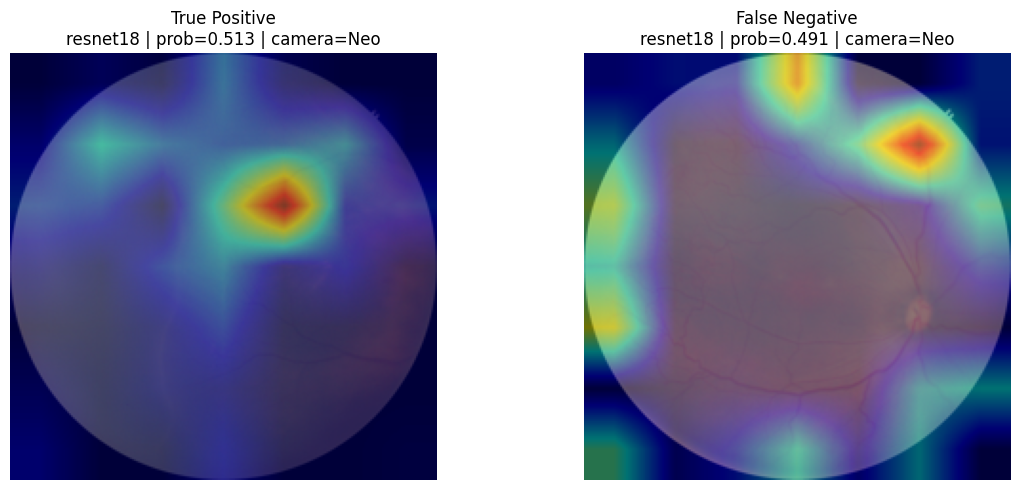

In [ ]:
# Cell 21: Grad-CAM on interesting cases — true positive vs false negative, saved to figures/
pred_df_check = test_df.reset_index(drop=True).copy()
pred_df_check["y_true"] = y_true_test
pred_df_check["y_pred"] = y_pred_test
pred_df_check["y_prob"] = y_probs_test

true_positive = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 1)].sort_values("y_prob", ascending=False).head(1)
false_negative = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 0)].head(1)

cases = []
if len(true_positive): cases.append(("True Positive", true_positive.iloc[0]))
if len(false_negative): cases.append(("False Negative", false_negative.iloc[0]))

fig, axes = plt.subplots(1, len(cases), figsize=(6 * len(cases), 5))
if len(cases) == 1: axes = [axes]

for ax, (label, row) in zip(axes, cases):
    img_pil = Image.open(row["filepath"]).convert("RGB")
    tensor = eval_tf(img_pil).unsqueeze(0)
    cam, prob = generate_gradcam(eval_model, tensor)
    overlay = overlay_heatmap(img_pil, cam)
    ax.imshow(overlay)
    ax.set_title(f"{label}\n{Config.MODEL_KEY} | prob={prob:.3f} | camera={row['camera']}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "gradcam_cases.png"), dpi=150)
plt.show()